In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
from tensorflow.keras.activations import relu,softmax

df = pd.read_csv('train.csv')
target0 = df[df.target == 0]
target1 = df[df.target == 1]
xs = np.vstack((target0,target1))
labels = target1.target
target1 = target1.drop('target',axis = 1)
target1 = target1.drop('id',axis = 1)
target1 = np.reshape(target1,(200,32,32,3))
target0 = target0.drop('id',axis = 1)
target0 = target0.drop('target',axis = 1)
target0 = np.reshape(target0,(1800,32,32,3))

original_labels = xs[:,3073]
xs = xs[:,1:3073]



datagen = ImageDataGenerator(
    zoom_range = 0.1,
    rotation_range = 20,
    horizontal_flip = True,
    vertical_flip = False,
    width_shift_range = 0.05,
    height_shift_range = 0.05
)

generator1 = datagen.flow(
    target1,
    batch_size = 200
)

original_labels = np.reshape(original_labels,(2000,1))
images = next(generator1)
label = np.ones((200,1))
images = np.reshape(images,(200,3072))
original_labels = np.vstack((original_labels,label))
xs = np.vstack((xs,np.reshape(images,(200,3072))))
for _ in range(8):
  images = next(generator1)
  label = np.ones((200,1))
  images = np.reshape(images,(200,3072))
  original_labels = np.vstack((original_labels,label))
  xs = np.vstack((xs,images))

generator0 = datagen.flow(
    target0,
    batch_size = 200
)

images = next(generator0)
label = np.zeros((200,1))
images = np.reshape(images,(200,3072))
original_labels = np.vstack((original_labels,label))
xs = np.vstack((xs,np.reshape(images,(200,3072))))
# for _ in range(0):
#   images = next(generator0)
#   label = np.zeros((200,1))
#   images = np.reshape(images,(200,3072))
#   original_labels = np.vstack((original_labels,label))
#   xs = np.vstack((xs,np.reshape(images,(200,3072))))

random_indices = np.random.permutation(len(original_labels))

xs = xs[random_indices]
original_labels = original_labels[random_indices]



In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization,Dropout,LayerNormalization
from tensorflow.keras.regularizers import l1,l2
from sklearn.model_selection import KFold
model = Sequential([
        Conv2D(32,(3,3) , activation = relu,input_shape = (32,32,3)),
        BatchNormalization(),
        Dropout(0.2),
        Conv2D(32,(2,2),activation = relu,kernel_regularizer=l1(0.001)),
        BatchNormalization(),
        Flatten(),
        Dense(256 , activation = relu),
        Dense(256, activation = relu),
        Dense(10 , activation = softmax)
])
class myCallBack(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs ={}):
    if(logs.get('accuracy') > 0.95):
      print("Model has accquired an accuracy of 85% on training dataset")
      self.model.stop_training = True
dynamiclr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.5,
    patience = 3,
    verbose = 1,
    mode ='auto',
    min_delta = 0.001,
    cooldown = 0,
    min_lr = 1e-6
  )
stopearly = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    start_from_epoch=6,
    patience = 2,
    verbose = 1,
    min_delta = 0.0001,
    restore_best_weights=True
  )
model.compile(
    optimizer =tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])
history = None
loss =[]
val_loss = []
from sklearn.model_selection import train_test_split
for _ in range(5):
  print(f'Fold : {_ + 1}')
  x_train,x_test,y_train,y_test = train_test_split(xs,original_labels,test_size = 0.1)
  history = model.fit(np.reshape(x_train/255,(3600,32,32,3)),y_train,callbacks = [myCallBack(),dynamiclr,stopearly],epochs = 100,validation_data=(np.reshape(x_test/255,(400,32,32,3)),y_test))
  loss.append(history.history['loss'])
  val_loss.append(history.history['val_loss'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold : 1
Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 23s 171ms/step - accuracy: 0.7123 - loss: 1.2697 - val_accuracy: 0.5200 - val_loss: 1.4847 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 162ms/step - accuracy: 0.9250 - loss: 0.4926 - val_accuracy: 0.5200 - val_loss: 3.9708 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9569 - loss: 0.3696Model has accquired an accuracy of 85% on training dataset
113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.9569 - loss: 0.3694 - val_accuracy: 0.5200 - val_loss: 3.5083 - learning_rate: 0.0010
Fold : 2
Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9730 - loss: 0.3105Model has accquired an accuracy of 85% on training dataset
113/113 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.9729 - loss: 0.3106 - val_accuracy: 0.6925 - val_loss: 0.9313 - learning_rate: 0.0010
Fold : 3
Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9827 - los

In [65]:
model.evaluate(np.reshape(x_test/255,(400,32,32,3)),y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9749 - loss: 0.2431


[0.23760557174682617, 0.9725000262260437]

In [66]:
def create_aug_data(target0,target1):
  aug_datagen = ImageDataGenerator(
    horizontal_flip = True,
  )

  aug_generator = aug_datagen.flow(
    target0,
    batch_size = 400
  )
  test_images = next(aug_generator)
  test_labels = np.zeros((400,1))

  aug_generator = aug_datagen.flow(
    target1,
    batch_size = 200
  )

  test_images = np.vstack((test_images,next(aug_generator)))
  test_labels = np.vstack((test_labels,np.ones((200,1))))
  test_images = np.vstack((test_images,next(aug_generator)))
  test_labels = np.vstack((test_labels,np.ones((200,1))))
  return [test_images,test_labels]



In [67]:
accuracy = [model.evaluate(create_aug_data(target0,target1)[0]/255,create_aug_data(target0,target1)[1])[1] for _ in range(5)]
x = np.mean(accuracy)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9037 - loss: 0.6479
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9111 - loss: 0.5903
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9122 - loss: 0.6055
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9156 - loss: 0.6326
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9162 - loss: 0.6308


In [68]:
accuracy

[0.7837499976158142,
 0.793749988079071,
 0.8087499737739563,
 0.8125,
 0.8149999976158142]

In [69]:
x

np.float64(0.8027499914169312)

In [70]:
y = pd.read_csv('test.csv')
idx = y.id
y = y.drop('id',axis = 1)
y = y/255
def label_generator(x):
  z = []
  for l in x:
    if l[0] > l[1]:
      z.append(0)
    else:
      z.append(1)
  return z
proba = model.predict(np.reshape(y,(2000,32,32,3)))


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


In [71]:
pred_target = label_generator(proba)

In [72]:
dataframe = pd.DataFrame({'id' : idx,'target' : pred_target})
dataframe.set_index('id')
dataframe.to_csv('submission.csv',index = False)

In [74]:
loss

[[0.9528971314430237, 0.48638734221458435, 0.3534439206123352],
 [0.32482200860977173],
 [0.25602713227272034],
 [0.23242074251174927],
 [0.22204282879829407]]

In [75]:
val_loss

[[1.4847266674041748, 3.970773696899414, 3.508303165435791],
 [0.9312558174133301],
 [0.6124278903007507],
 [0.5063095092773438],
 [0.23760557174682617]]

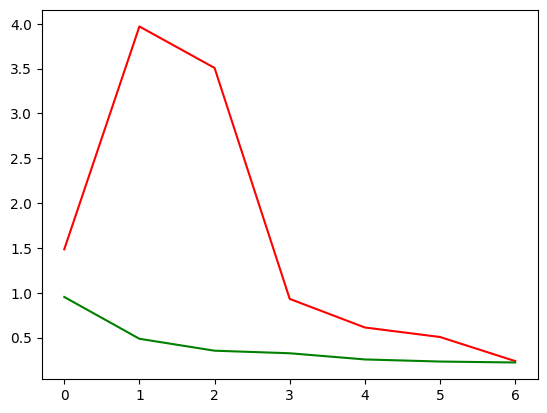

In [83]:
lossx = []
for a in loss:
  if(type(a) == list):
      for i in range(len(a)):
        lossx.append(a[i])
  else:
    lossx.append(a)
lossy = []

for a in val_loss:
  if(type(a) == list):
      for i in range(len(a)):
        lossy.append(a[i])
  else:
    lossy.append(a)
plt.figure()
plt.plot(lossy,color = 'red')
plt.plot(lossx,color = 'green')
plt.show()


In [84]:
lossx

[0.9528971314430237,
 0.48638734221458435,
 0.3534439206123352,
 0.32482200860977173,
 0.25602713227272034,
 0.23242074251174927,
 0.22204282879829407]

In [85]:
lossy

[1.4847266674041748,
 3.970773696899414,
 3.508303165435791,
 0.9312558174133301,
 0.6124278903007507,
 0.5063095092773438,
 0.23760557174682617]